**Ch121a | Module 3: Periodic DFT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module3_Periodic-DFT/notebooks/05_aimd_and_mlff.ipynb)

# Notebook 5: Ab-initio MD & Machine-learned Force-fields

---

## Learning Objectives

By the end of this notebook you will be able to:

- Describe the **hierarchy of atomistic simulation methods** from wavefunction QM to classical MD
- Identify the **time- and length-scales** accessible to: QM, DFT/AIMD, ReaxFF, MLIPs, and classical MD
- Explain how **Ab-initio Molecular Dynamics (AIMD)** works and how it differs from classical MD
- Compare Born–Oppenheimer MD and Car–Parrinello MD
- Set up VASP INCAR tags for AIMD simulations
- Describe what a **Machine-learned Interatomic Potential (MLIP / MLFF)** is and why it is useful
- Survey key MLFF architectures: Behler–Parrinello, GAP/SOAP, DeePMD, NequIP, **MACE**
- Explain the **MACE architecture**: equivariant message passing and the ACE basis
- Understand VASP's built-in **on-the-fly active learning** ML-FF workflow
- Use **universal potentials** (MACE-MP-0, CHGNet, SevenNet) for zero-shot simulations
- Articulate the **limitations** of MLIPs: transferability, long-range effects, and validation
- Explain how MLIPs are **bridging the gap** between DFT accuracy and classical MD scale in materials science

## 0. The Atomistic Simulation Landscape

Atomistic simulations span a wide range of **accuracy** and **computational cost**.
No single method covers all time- and length-scales, so practitioners choose the right tool for the question at hand.

| Method | Physical basis | Typical system size | Typical timescale | Accuracy | Key codes |
|---|---|---|---|---|---|
| **Post-Hartree–Fock QM** (CCSD(T), MP2) | Wavefunction | 1–50 atoms | single-point | Benchmark | Gaussian, ORCA, PySCF |
| **DFT** | Electron density | 1–1 000 atoms | single-point / ps | High | VASP, QE, CP2K |
| **AIMD** | DFT forces on-the-fly | 10–500 atoms | fs–100 ps | High (DFT) | VASP, CP2K |
| **ReaxFF** | Reactive bond-order FF | 10³–10⁶ atoms | ps–ns | Medium | LAMMPS, ADF |
| **MLIP / MLFF** | ML fit to DFT PES | 10²–10⁶ atoms | ps–µs | ≈ DFT | MACE, DeePMD, NequIP |
| **Classical FF** | Empirical functions | 10³–10⁹ atoms | ns–ms | Low–Medium | LAMMPS, GROMACS, NAMD |

**The central message of this lecture**: MLIPs sit in the gap between expensive DFT and
fast-but-inaccurate classical force-fields, delivering near-DFT accuracy at a fraction of the cost.
Understanding where each method succeeds — and fails — is essential for modern computational materials science.

> **ReaxFF** deserves a special mention. It handles bond-breaking and formation through a bond-order formalism,
> making it useful for reactive systems (combustion, corrosion, crack propagation). However, parameters are
> element-pair specific and require careful validation. MLIPs increasingly replace ReaxFF for systems where
> DFT reference data can be generated.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

# Each entry: (label, x_lo, x_hi, y_lo, y_hi, facecolor)
# x = log10(number of atoms), y = log10(time in seconds)
methods = [
    ('Post-HF QM\n(CCSD(T), MP2)',   0.0, 1.7,  -15, -11,  '#9467bd'),
    ('DFT / AIMD',                   0.5, 2.8,  -13,  -9,  '#1f77b4'),
    ('ReaxFF',                       2.5, 6.2,  -12,  -7,  '#2ca02c'),
    ('MLIP / MLFF',                  2.0, 6.5,  -11,  -5,  '#ff7f0e'),
    ('Classical MD',                 3.0, 9.0,  -11,  -2,  '#d62728'),
]

for label, xl, xh, yl, yh, color in methods:
    rect = FancyBboxPatch((xl, yl), xh-xl, yh-yl,
                          boxstyle='round,pad=0.15',
                          facecolor=color, edgecolor='white',
                          linewidth=2, alpha=0.45, zorder=2)
    ax.add_patch(rect)
    ax.text((xl+xh)/2, (yl+yh)/2, label,
            ha='center', va='center', fontsize=10.5,
            fontweight='bold', color='black', zorder=3)

# Highlight MLIP overlap arrow
ax.annotate(
    'MLIPs bridge\nDFT accuracy\nwith MD scale',
    xy=(5.2, -8.0), xytext=(7.2, -10.5),
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2),
    fontsize=10, color='darkorange', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd', edgecolor='#ff7f0e', lw=1.5),
    zorder=5
)

# Axes formatting
x_ticks = list(range(10))
x_labels = ['1', '10', '10²', '10³', '10⁴', '10⁵', '10⁶', '10⁷', '10⁸', '10⁹']
ax.set_xticks(x_ticks); ax.set_xticklabels(x_labels, fontsize=11)

y_ticks = [-15, -12, -9, -6, -3, 0]
y_labels = ['1 fs', '1 ps', '1 ns', '1 µs', '1 ms', '1 s']
ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels, fontsize=12)

ax.set_xlim(-0.3, 9.5)
ax.set_ylim(-16, 1)
ax.set_xlabel('System size (number of atoms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accessible simulation time', fontsize=13, fontweight='bold')
ax.set_title(
    'Atomistic Simulation Methods: Time & Length Scale Landscape',
    fontsize=14, fontweight='bold', pad=12
)
ax.grid(True, alpha=0.35, linestyle='--', zorder=0)

# Legend patches
patches = [mpatches.Patch(facecolor=c, alpha=0.7, label=l.split('\n')[0])
           for l, *_, c in methods]
ax.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()
print('Figure: each shaded region shows the (system size, time) space accessible to a given method.')
print('MLIP/MLFF (orange) overlaps substantially with both DFT (blue) and Classical MD (red),')
print('enabling DFT-accuracy simulations at sizes and timescales unreachable by AIMD.')

## 1. Ab-initio Molecular Dynamics (AIMD) with VASP

### What is AIMD?

In classical MD, atoms interact via empirical **force-fields** — parametrized functions fitted to experiment or quantum data. In **AIMD**, forces are computed *on-the-fly* from a DFT calculation at every time step. No force-field approximation is made.

$$F_I = -\nabla_{\mathbf{R}_I} E_{\text{DFT}}[\{\mathbf{R}\}]$$

The electronic structure problem is solved at each MD step, giving forces that are essentially exact within the chosen DFT approximation.

### Born-Oppenheimer MD vs. Car-Parrinello MD

| | Born-Oppenheimer MD (BOMD) | Car-Parrinello MD (CPMD) |
|---|---|---|
| Electronic ground state | Fully converged at each step | Propagated as fictitious classical degrees of freedom |
| SCF per step | Yes | No (electron mass parameter $\mu$) |
| Stability | Robust | Requires careful tuning of $\mu$ and time step |
| VASP support | ✅ Default | (use CPMD code) |

VASP implements **BOMD** exclusively (`IBRION=0`).

### Key VASP AIMD Tags

```
IBRION = 0       ! MD run (no ionic relaxation)
NSW    = 5000    ! Number of MD steps
POTIM  = 2.0     ! Time step in fs
TEBEG  = 300     ! Starting temperature (K)
TEEND  = 300     ! Ending temperature (K)  (same → NVT)
SMASS  = 0       ! Nosé–Hoover thermostat (0=Nosé mass auto)
MDALGO = 2       ! Nosé–Hoover chain thermostat
ISYM   = 0       ! Symmetry OFF for MD
```

The ionic equations of motion are integrated with the Verlet algorithm. The Nosé–Hoover thermostat (`MDALGO=2`) enforces NVT (canonical) ensemble sampling.

### Cost vs. Classical MD

Each AIMD step requires a DFT self-consistent field (SCF) cycle:

- **System size**: practical limit ~100–500 atoms (vs. millions for classical MD)
- **Timescale**: tens to hundreds of picoseconds (vs. microseconds for classical MD)
- **Cost**: roughly $\mathcal{O}(N^3)$ with system size $N$ for standard DFT

### When to Use AIMD

- Reaction mechanisms and free-energy barriers in solution
- Phase transitions and melting
- Liquid-state simulations (water, molten salts, liquid metals)
- Amorphous structure generation (melt-quench protocol)
- Vibrational spectroscopy (IR/Raman via dipole/polarizability autocorrelation)

### Example: Water at 300 K — INCAR snippet

```
# VASP AIMD INCAR for liquid water (NVT, 300 K)
SYSTEM  = Water 300K NVT
ISTART  = 0
ICHARG  = 2
ENCUT   = 400
EDIFF   = 1E-5
PREC    = Normal

# MD settings
IBRION  = 0
NSW     = 10000    ! 10000 steps × 0.5 fs = 5 ps
POTIM   = 0.5
TEBEG   = 300
TEEND   = 300
SMASS   = 0
MDALGO  = 2
ISYM    = 0

# DFT settings
GGA     = PE       ! PBE functional
IVDW    = 11       ! DFT-D3 dispersion (important for water!)
```

## 2. Machine-learned Force-fields (MLFFs) / MLIPs

### 2.1 Motivation

AIMD is accurate but expensive. Classical force-fields are fast but limited in transferability.
**MLFFs** (also called **Machine-learned Interatomic Potentials**, MLIPs) aim to:

$$\underbrace{E_{\text{MLFF}}(\{\mathbf{R}\})}_{\approx\, E_{\text{DFT}}} \quad \text{at} \quad
\underbrace{\text{classical MD cost}}_{\ll\, \text{DFT cost}}$$

The key physical insight enabling this: the energy is **short-ranged** — most of the contribution to
the potential energy of atom $i$ comes from its local neighborhood $\mathcal{A}_i$.
The total energy is therefore decomposed as a sum of **atomic energies**:

$$E = \sum_{i=1}^{N} \varepsilon_i(\mathcal{A}_i)$$

A ML model learns $\varepsilon_i$ from a database of DFT reference calculations (energies, forces, stresses).
Forces are obtained analytically by automatic differentiation:

$$\mathbf{F}_i = -\nabla_{\mathbf{R}_i} E_{\text{MLFF}}$$

### 2.2 Descriptor-Based vs. Message-Passing Architectures

Two broad families of MLFFs have emerged:

**Descriptor-based** (first generation): compute a fixed, hand-crafted descriptor of the local environment,
then feed it to a standard regression model (NN or Gaussian process).
Examples: Behler–Parrinello NN (2007), GAP/SOAP (2010), DeePMD (2018).

**Message-passing / equivariant GNN** (second generation): represent each atom as a node in a graph;
atoms exchange messages with neighbors using learnable, symmetry-respecting functions.
Examples: NequIP (2022), Allegro (2023), **MACE** (2023).

| Architecture | Year | Type | Key feature |
|---|---|---|---|
| **Behler–Parrinello NN** | 2007 | Descriptor + FF-NN | First general NN potential |
| **GAP / SOAP** | 2010 | Descriptor + GP | Uncertainty quantification |
| **DeePMD** | 2018 | Descriptor + deep NN | Scalable, GPU-accelerated |
| **NequIP** | 2022 | Equivariant GNN (E3) | Data-efficient, accurate |
| **Allegro** | 2023 | Local equivariant GNN | Massively parallel |
| **MACE** | 2023 | Equivariant GNN + ACE | State-of-the-art accuracy |
| **VASP ML-FF** | 2020+ | Bayesian / moment tensor | Integrated in VASP 6 |

### 2.3 General Training Workflow

```
1. Collect DFT reference data
   (energies, forces, stresses for diverse structures)
         ↓
2. Train MLFF on reference database
   (minimize loss: w_E·ΔE² + w_F·ΔF² + w_σ·Δσ²)
         ↓
3. Validate on held-out DFT data
   (force RMSE < ~50 meV/Å is a common target)
         ↓
4. Run long MD with MLFF
   (ns–μs timescales, 10³–10⁶ atoms)
         ↓
5. Active learning: flag uncertain structures,
   recompute DFT, retrain → iterate
```

The **loss function** typically weights energies, forces, and stresses:

$$\mathcal{L} = w_E \sum_{s} \left(\frac{E_s^{\text{DFT}} - E_s^{\text{MLFF}}}{N_s}\right)^2
+ w_F \sum_{s,i} \|\mathbf{F}_{si}^{\text{DFT}} - \mathbf{F}_{si}^{\text{MLFF}}\|^2
+ w_{\sigma} \sum_{s} \|\boldsymbol{\sigma}_s^{\text{DFT}} - \boldsymbol{\sigma}_s^{\text{MLFF}}\|^2$$

where $s$ indexes structures and $N_s$ is the number of atoms. Force training is crucial because forces
provide $3N$ data points per structure — far more signal than the single energy value.

## 3. MACE: Architecture and Design Principles

**MACE** (Messages passing Atomic Cluster Expansion) is currently among the most accurate general-purpose MLIPs.
It combines two powerful ideas: **equivariant graph neural networks** and the **Atomic Cluster Expansion (ACE)**.

### 3.1 Physical Symmetries: Equivariance

Any interatomic potential must respect the symmetries of physics:

- **Translational invariance**: $E(\{\mathbf{R}_i + \mathbf{t}\}) = E(\{\mathbf{R}_i\})$
- **Rotational equivariance**: forces transform as vectors under rotation ($\mathbf{F}' = R\mathbf{F}$), where $R$ is the rotation matrix
- **Permutation invariance**: swapping identical atoms leaves $E$ unchanged

MACE is built on **E(3)-equivariant** operations — the symmetry group of 3D rotations, reflections,
and translations. This means hidden features transform predictably under rotation,
allowing the network to be both expressive and physically correct by construction.

### 3.2 The Atomic Cluster Expansion (ACE) Basis

ACE provides a systematic, body-order decomposition of the local energy:

$$\varepsilon_i = \sum_{\nu=1}^{\nu_{\max}} \sum_{\mathbf{z}} c_{\mathbf{z}}^{(\nu)} A_{i,\mathbf{z}}^{(\nu)}$$

where $A_{i,\mathbf{z}}^{(\nu)}$ are symmetrized $\nu$-body basis functions constructed from
atomic positions within a cutoff radius $r_{\text{cut}}$, and $c_{\mathbf{z}}^{(\nu)}$ are learned coefficients.
Higher $\nu$ captures many-body effects (3-body angles, 4-body dihedrals, etc.).

MACE embeds ACE features inside a message-passing GNN, dramatically increasing expressiveness
without abandoning the systematic nature of ACE.

### 3.3 MACE Forward Pass

The computation graph for atom $i$ proceeds as follows:

1. **Node initialization**: embed atom $i$'s element type as a learnable vector $\mathbf{h}_i^{(0)}$.
2. **Edge features**: for each neighbor $j$ within cutoff $r_{\text{cut}}$,
   compute relative displacement $\hat{\mathbf{r}}_{ij}$ and radial basis $R(r_{ij})$.
3. **Message construction** (interaction block):
   $$\mathbf{m}_{ij} = W^{(l)} \mathbf{h}_j^{(l)} \otimes_\text{CG} Y_L(\hat{\mathbf{r}}_{ij}) \cdot R(r_{ij})$$
   where $\otimes_\text{CG}$ is a Clebsch–Gordan tensor product (ensures equivariance)
   and $Y_L$ are spherical harmonics.
4. **Aggregation**: $\mathbf{h}_i^{(l+1)} = \mathbf{h}_i^{(l)} + \sum_{j \in \mathcal{N}_i} \mathbf{m}_{ij}$
5. **Readout** (after $L$ interaction blocks):
   $\varepsilon_i = \text{MLP}(\mathbf{h}_i^{(L)})$
6. **Total energy**: $E = \sum_i \varepsilon_i$; forces via automatic differentiation.

Typically $L=2$ interaction blocks are used. Each block has its own set of learnable parameters.

### 3.4 Why MACE is State-of-the-Art

| Property | Behler–Parrinello | GAP/SOAP | MACE |
|---|---|---|---|
| Body order | 2–3 (with angle terms) | Up to ~4 | Effectively very high via GNN |
| Symmetry by construction | ✅ | ✅ | ✅ (E3-equivariant) |
| Data efficiency | Medium | High | **Very high** |
| Speed (inference) | Fast | Slow (GP scales as $N_\text{train}$) | Fast (NN, GPU) |
| Uncertainty quantification | Limited | ✅ native | Via ensembles or conformal prediction |
| Foundation models | ❌ | ❌ | ✅ MACE-MP-0 |

### 3.5 MACE-MP-0: A Universal Potential

**MACE-MP-0** (Batatia et al., 2024) is a **foundation model** for atomistic simulation:

- Trained on **~150 000 structures** from the Materials Project (MP)
- Covers **89 elements** of the periodic table
- Achieves ~50–100 meV/Å force RMSE on MP test set
- Can be used **zero-shot** for geometry optimization, MD, and phonons
- Can be **fine-tuned** on system-specific DFT data for higher accuracy

```python
# Using MACE-MP-0 with ASE (zero-shot, no DFT required)
from mace.calculators import mace_mp
from ase.io import read
from ase.optimize import BFGS

atoms = read('POSCAR')                    # read structure
calc  = mace_mp(model='medium', default_dtype='float32')
atoms.set_calculator(calc)

opt = BFGS(atoms)
opt.run(fmax=0.05)                        # relax to 50 meV/Å
print(f'Energy: {atoms.get_potential_energy():.4f} eV')
```

Other universal potentials: **CHGNet** (includes charge/magnet DoF, Deng et al. 2023),
**SevenNet** (efficient equivariant GNN, Park et al. 2024),
**M3GNet** (Materials 3-body Graph Network, Chen & Ong 2022).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5)
ax.axis('off')
ax.set_title('MACE Architecture: Equivariant Message-Passing Atomic Cluster Expansion',
             fontsize=12, fontweight='bold', pad=10)

COLORS = ['#e8d5f5', '#cce5ff', '#d4edda', '#d4edda', '#fff3cd', '#f8d7da']
LABELS = [
    'Atomic\nStructure',
    'Node & Edge\nInitialization',
    'Interaction\nBlock 1\n(E3-equivariant)',
    'Interaction\nBlock 2\n(E3-equivariant)',
    'Readout\n(MLP)',
    'Energy E\n+ Forces F',
]
SUBS = [
    'Positions $\\mathbf{R}_i$\n element type $z_i$',
    'Node: embed $z_i$\nEdge: $\\hat{\\mathbf{r}}_{ij}$, $R(r_{ij})$\nsph. harmonics $Y_L$',
    'CG tensor product\nmessage passing\n$\\mathbf{h}_i^{(1)}$',
    'CG tensor product\nmessage passing\n$\\mathbf{h}_i^{(2)}$',
    'Sum over atoms\n$\\varepsilon_i = \\text{MLP}(\\mathbf{h}_i^{(2)})$',
    '$E = \\sum_i \\varepsilon_i$\n$\\mathbf{F}_i = -\\nabla_{\\mathbf{R}_i} E$\n(autograd)',
]

xs = [0.15, 2.3, 4.4, 6.8, 9.2, 11.4]
w, h = 1.9, 4.0
for i, (x, color, label, sub) in enumerate(zip(xs, COLORS, LABELS, SUBS)):
    rect = FancyBboxPatch((x, 0.4), w, h, boxstyle='round,pad=0.1',
                          facecolor=color, edgecolor='gray', linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, 0.4 + h*0.72, label,
            ha='center', va='center', fontsize=9, fontweight='bold', zorder=3)
    ax.text(x + w/2, 0.4 + h*0.30, sub,
            ha='center', va='center', fontsize=7.5, color='#333333', zorder=3)
    if i < len(xs) - 1:
        ax.annotate('', xy=(xs[i+1], 0.4 + h/2), xytext=(x + w, 0.4 + h/2),
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=2.0), zorder=4)

# Back-arrow: gradients flow back (autograd)
ax.annotate('autograd\n(backprop)', xy=(xs[4] + w, 0.4 + h*0.25),
            xytext=(xs[5] + w/2, 0.4 + h*0.08),
            fontsize=7.5, ha='center', color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5,
                            connectionstyle='arc3,rad=0.3'), zorder=5)

plt.tight_layout()
plt.show()
print('The two Interaction Blocks (green) are the core of MACE.')
print('Each uses Clebsch–Gordan (CG) tensor products to combine neighbor features')
print('in a way that is equivariant under 3D rotations (E3 symmetry group).')

## 4. VASP ML-FF: On-the-fly Active Learning

VASP 6 ships with a built-in ML force-field module (accessed via `ML_LMLFF = .TRUE.`).
It implements **on-the-fly active learning**: the force field is trained *during* the MD run,
automatically selecting which configurations need DFT computation.

### 4.1 Algorithm Overview

VASP ML-FF is based on **Moment Tensor Potentials (MTPs)** with **Bayesian linear regression**
for uncertainty estimation. At each MD step:

1. **Compute uncertainty**: evaluate the Bayesian posterior variance on the predicted forces
2. **Decision**:
   - If uncertainty < threshold → accept MLFF forces, advance MD step **(fast)**
   - If uncertainty > threshold → run a full DFT calculation, add to training set, retrain **(slow)**
3. **Retrain**: update the Bayesian model (analytic update, no iterative optimization needed)
4. **Repeat**: as the training set grows, fewer DFT calls are needed

Over a long run, the fraction of steps requiring DFT drops from ~100% (early) to <5% (late),
giving a ~10–50× speedup over pure AIMD.

### 4.2 Key VASP INCAR Tags

```
# ─── ML-FF activation ───────────────────────────────────────────
ML_LMLFF  = .TRUE.   ! Enable on-the-fly ML-FF
ML_ISTART = 0        ! 0 = train from scratch
                     ! 1 = read ML_FF, continue training
                     ! 2 = read ML_FF, production run (no retraining)

# ─── MD settings ────────────────────────────────────────────────
IBRION    = 0        ! MD
NSW       = 50000    ! Total MD steps (model learns early, then runs fast)
POTIM     = 2.0      ! Time step (fs)
TEBEG     = 1000     ! Temperature (K)
MDALGO    = 2        ! Nosé–Hoover thermostat (NVT)

# ─── Optional tuning ────────────────────────────────────────────
ML_THRESHOLD = 0.1   ! Force uncertainty threshold (eV/Å); lower = more DFT calls
ML_RCUT1  = 6.0      ! Cutoff for 2-body interactions (Å)
ML_RCUT2  = 4.0      ! Cutoff for 3-body interactions (Å)
```

### 4.3 Output Files

| File | Contents |
|---|---|
| `ML_FF` | Trained force field (binary); use with `ML_ISTART=2` for production |
| `ML_ABN` | AB-initio training set (energies, forces, stresses) |
| `ML_LOGFILE` | Per-step log: DFT/MLFF flag, uncertainty, energy |
| `OUTCAR` | Standard VASP output; energy and forces at every step |

### 4.4 Three-Phase Workflow

A practical VASP ML-FF workflow has three phases:

```
Phase 1 – Training run (ML_ISTART=0, NSW=10000–50000)
   Model starts empty; most steps are DFT. Database builds up.
   → Output: ML_FF, ML_ABN

Phase 2 – Extended training / refinement (ML_ISTART=1, NSW=50000+)
   Model loaded; continued refinement at low temperatures or new phases.
   DFT fraction drops. → Output: updated ML_FF

Phase 3 – Production run (ML_ISTART=2, NSW=millions)
   No DFT: pure MLFF. Near-classical MD speed.
   Compute diffusion, free energy, transport, …
```

### 4.5 Exporting to LAMMPS

The trained VASP ML-FF can be exported to LAMMPS via the `mlff_to_lammps.py` utility
provided with VASP, enabling very long production runs on HPC clusters without VASP licenses:

```bash
python mlff_to_lammps.py ML_FF > lammps_mlff.params
```

In the LAMMPS input:
```
pair_style  mlff
pair_coeff  * * lammps_mlff.params Li O
```

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off')
ax.set_title('VASP ML-FF: On-the-fly Active Learning Workflow',
             fontsize=13, fontweight='bold', pad=8)

def box(ax, x, y, w, h, text, color='#cce5ff', fontsize=9.5, bold=True):
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                          facecolor=color, edgecolor='#555', linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    fw = 'bold' if bold else 'normal'
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight=fw, zorder=3)

def diamond(ax, cx, cy, hw, hh, text, color='#fff3cd', fontsize=9):
    xs = [cx, cx+hw, cx, cx-hw, cx]
    ys = [cy+hh, cy, cy-hh, cy, cy+hh]
    ax.fill(xs, ys, facecolor=color, edgecolor='#555', linewidth=1.5, zorder=2)
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', zorder=3)

def arrow(ax, x1, y1, x2, y2, label='', color='#333', lw=1.8, rad=0.0):
    style = f'arc3,rad={rad}'
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=style), zorder=4)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=8.5, color=color, fontweight='bold', zorder=5)

# Boxes
box(ax, 4.5, 6.0, 3.0, 0.7, 'Start MD run\n(ML_ISTART=0)', color='#d4edda')
box(ax, 4.5, 4.8, 3.0, 0.7, 'Compute atom positions\nat step t', color='#cce5ff')
diamond(ax, 6.0, 3.7, 2.2, 0.7, 'Uncertainty\n> threshold?', color='#fff3cd')

# DFT branch (left)
box(ax, 0.4, 2.8, 2.5, 0.75, 'Run DFT\n(VASP SCF)', color='#f8d7da')
box(ax, 0.4, 1.7, 2.5, 0.75, 'Add to\ntraining set', color='#f8d7da')
box(ax, 0.4, 0.6, 2.5, 0.75, 'Retrain ML-FF\n(Bayesian update)', color='#f8d7da')

# MLFF branch (right)
box(ax, 9.1, 2.8, 2.5, 0.75, 'Use MLFF forces\n(fast!)', color='#d4edda')

# Converge box
box(ax, 4.5, 0.6, 3.0, 0.75, 'Advance MD step\nt → t+1', color='#e8d5f5')

# Arrows - main flow
arrow(ax, 6.0, 6.0, 6.0, 5.5)
arrow(ax, 6.0, 4.8, 6.0, 4.4)

# Yes (DFT) branch
arrow(ax, 3.8, 3.7, 2.9, 3.175, label='Yes\n(DFT)', color='#c0392b')
arrow(ax, 1.65, 2.8, 1.65, 2.45)
arrow(ax, 1.65, 1.7, 1.65, 1.35)
# DFT branch rejoins
arrow(ax, 2.9, 0.975, 4.5, 0.975)

# No (MLFF) branch
arrow(ax, 8.2, 3.7, 9.1, 3.175, label='No\n(MLFF)', color='#27ae60')
arrow(ax, 10.35, 2.8, 10.35, 2.0)
# MLFF branch rejoins
ax.annotate('', xy=(7.5, 0.975), xytext=(10.35, 2.0),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8,
                            connectionstyle='arc3,rad=-0.3'), zorder=4)

# Loop back to top
ax.annotate('', xy=(4.5, 5.15), xytext=(4.0, 5.15),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=4)
ax.plot([4.0, 4.0], [0.975, 5.15], color='#555', lw=1.8, zorder=3)
arrow(ax, 4.5, 0.975, 4.0, 0.975)

# Annotation: shrinking DFT fraction
ax.text(0.05, 0.1, 'Early run: ~100% DFT\nLate run: <5% DFT  →  10–50× speedup',
        fontsize=8.5, color='#c0392b', style='italic', zorder=5)

plt.tight_layout()
plt.show()
print('The on-the-fly loop ensures the model is trained only on configurations it actually encounters,')
print('making it more efficient than training on a pre-computed static database.')

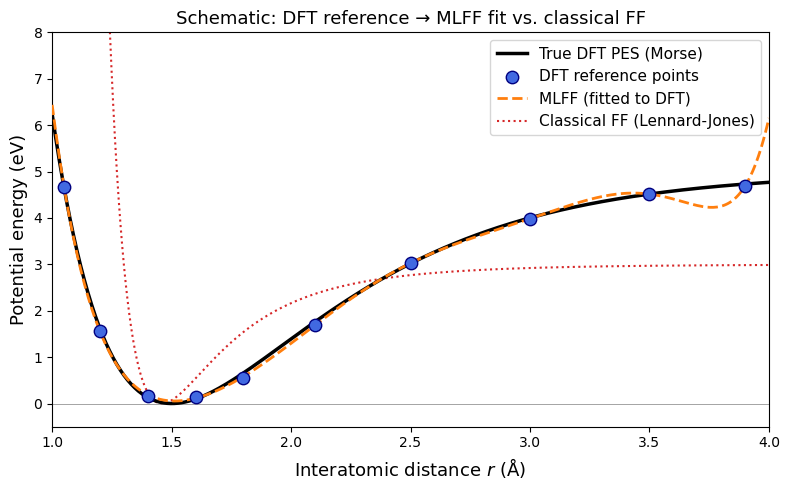

Key takeaway: MLFF (orange dashed) closely tracks the DFT PES (black).
The classical FF (red dotted) captures the rough shape but misses accuracy.
With enough DFT reference points, MLFF error → DFT error (< ~50 meV/Å).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── Concept illustration: fitting a 1D PES with a simple NN surrogate ───
# This is a schematic — NOT an actual MLFF library call.
# We use numpy to mimic what a real MLFF training loop does.

np.random.seed(42)
rng = np.random.default_rng(42)

# True PES: Morse potential  V(r) = D_e*(1 - exp(-a*(r-r0)))^2
D_e, a, r0 = 5.0, 1.5, 1.5   # eV, Å^-1, Å
r = np.linspace(1.0, 4.0, 400)
V_true = D_e * (1 - np.exp(-a * (r - r0)))**2

# DFT 'reference' points (sparse, noisy)
r_dft = np.array([1.05, 1.2, 1.4, 1.6, 1.8, 2.1, 2.5, 3.0, 3.5, 3.9])
V_dft = D_e * (1 - np.exp(-a * (r_dft - r0)))**2 + rng.normal(0, 0.05, len(r_dft))

# Classical force-field: Lennard-Jones (deliberately wrong well depth)
eps_lj, sigma_lj = 3.0, 1.3
V_lj = 4*eps_lj * ((sigma_lj/r)**12 - (sigma_lj/r)**6)
V_lj = V_lj - V_lj.min()   # shift to zero

# 'MLFF' surrogate: polynomial fit to DFT points (mimics NN regression)
coeffs = np.polyfit(r_dft, V_dft, deg=8)
V_mlff = np.polyval(coeffs, r)

# ─── Plot ───
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(r, V_true,  'k-',  lw=2.5, label='True DFT PES (Morse)', zorder=3)
ax.scatter(r_dft, V_dft, color='royalblue', s=80, zorder=5,
           label='DFT reference points', edgecolors='navy')
ax.plot(r, V_mlff,  'tab:orange', lw=2, ls='--', label='MLFF (fitted to DFT)', zorder=4)
ax.plot(r, V_lj,    'tab:red',    lw=1.5, ls=':', label='Classical FF (Lennard-Jones)', zorder=2)

ax.set_xlim(1.0, 4.0)
ax.set_ylim(-0.5, 8)
ax.set_xlabel('Interatomic distance $r$ (Å)', fontsize=13)
ax.set_ylabel('Potential energy (eV)', fontsize=13)
ax.set_title('Schematic: DFT reference → MLFF fit vs. classical FF', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

print('Key takeaway: MLFF (orange dashed) closely tracks the DFT PES (black).')
print('The classical FF (red dotted) captures the rough shape but misses accuracy.')
print('With enough DFT reference points, MLFF error → DFT error (< ~50 meV/Å).')

## 5. Limitations and Challenges of MLIPs

MLIPs are powerful, but they are **not a silver bullet**. Understanding their limitations
is essential for reliable use in research.

### 5.1 Domain of Applicability (Transferability)

An MLIP is only reliable for configurations **within** (or near) its training distribution.
If the MD trajectory explores unfamiliar chemical environments — new coordination numbers,
phases, or compositions — the MLIP can give catastrophically wrong forces.

> **Rule of thumb**: always validate forces on held-out DFT calculations *before* long production runs.
> A force RMSE < 50–100 meV/Å on representative structures is a minimum requirement.

### 5.2 Local Approximation and Missing Long-Range Physics

Standard MLIPs use a **cutoff radius** ($r_{\text{cut}} \approx 5\text{–}8$ Å) and are therefore
inherently local. They miss:

- **Dispersion / van der Waals**: London forces fall off as $r^{-6}$; important for molecular crystals,
  graphene, and layered materials. Some MLIPs add a D3 correction post-hoc.
- **Long-range electrostatics**: Ionic systems, charged defects, and polar surfaces need Ewald sums.
  Models like **CHGNet** include charge and magnetic degrees of freedom explicitly.
- **Charge transfer**: Bond polarization over long distances (e.g., in electrochemical interfaces)
  is not captured unless special descriptors are added.

### 5.3 Extrapolation Failures

Unlike physics-based FFs (which have sensible behavior outside their range),
ML models can **fail silently** by producing smooth but incorrect PES surfaces.
Symptoms include:

- Atoms flying apart (unphysically high energies)
- Pair distances collapsing to zero
- Oscillatory forces leading to energy non-conservation

**Mitigation**: active learning, uncertainty quantification (GAP, Bayesian NNs, ensemble MLIPs),
and regular DFT spot-checks during production.

### 5.4 Training Data Requirements

A reliable system-specific MLIP typically requires:

| System type | Approximate DFT structures needed |
|---|---|
| Simple elemental metal | 500–2 000 |
| Binary alloy | 1 000–5 000 |
| Multi-component oxide | 5 000–20 000 |
| Reactive surface + adsorbates | 10 000–50 000 |

Each DFT single-point can take minutes to hours on an HPC cluster, making dataset generation
the bottleneck. **Universal potentials** (MACE-MP-0, CHGNet) reduce this cost by fine-tuning
instead of training from scratch.

### 5.5 Spin, Magnetism, and Excited States

Most MLIPs are trained on **ground-state DFT** and do not account for:

- Magnetic ordering (spin-up/down, non-collinear spins) — except **CHGNet**, which uses per-atom magnetic moments as input features to improve energy predictions in magnetic materials, though it does not directly predict magnetic phase transitions
- Spin crossover or magnetic phase transitions
- Electronically excited states (relevant for photocatalysis, radiation damage)

### 5.6 Rare Events and Free Energy Barriers

Even a perfect MLIP cannot overcome the **timescale problem**: thermally activated events
(diffusion hops, nucleation, bond breaking) may have barriers of 0.5–2 eV,
giving rates of $\sim 10^{-9}$–$10^{-35}$ s$^{-1}$ at room temperature.
**Enhanced sampling** methods (NEB, metadynamics, umbrella sampling, replica exchange)
are needed to compute free-energy landscapes efficiently, and these remain applicable with MLIPs.

### 5.7 Validation Checklist for MLIP-MD

Before trusting MLIP-MD results:

- [ ] Force RMSE on test set < 50–100 meV/Å
- [ ] Energy RMSE per atom < 5–10 meV/atom
- [ ] Lattice parameters within 1–2% of DFT
- [ ] Phonon dispersion matches DFT (for crystalline solids)
- [ ] Radial distribution function consistent with AIMD at same T
- [ ] Energy conservation in NVE ensemble (drift < 0.1 meV/atom/ps)
- [ ] Stress tensor consistent with DFT for a range of volumes

## 6. MLIPs Bridging the Gap in Materials Science

The ability to run DFT-accurate MD on large systems for long times unlocks a new class of
materials science problems that were previously inaccessible.

### 6.1 Battery Materials

**Solid-state electrolytes** (e.g., Li₇La₃Zr₂O₁₂, Li₃PS₄) require Li-ion diffusion
at timescales of ns–µs and length scales of >10 nm.

- AIMD: limited to ~100 ps → extrapolation to room temperature is unreliable
- MLIP-MD: can directly compute the diffusion coefficient at 300 K in ns-scale runs
- Example: Huang et al. (2021) used DeePMD to compute Li diffusivity in LGPS (Li₁₀GeP₂S₁₂)
  with 10 000-atom supercells, matching experiment without empirical fitting.

### 6.2 Heterogeneous Catalysis

Reaction mechanisms on surfaces involve rare events (adsorption, diffusion, bond-breaking).

- MLIP + NEB: compute accurate reaction barriers for 100s of pathways quickly
- MLIP + metadynamics: sample the free-energy surface at finite temperature
- MLIP + grand-canonical MC: simulate adsorption isotherms for MOFs and zeolites
- Universal potentials enable rapid screening of catalysts across composition space

### 6.3 Amorphous Materials and Glasses

Glass structure is formed by **melt-quench** simulations. DFT is too slow for realistic
quench rates; classical FFs miss subtle structural details.

- MLIP-MD melt-quench reproduces neutron/X-ray scattering data quantitatively
- Studied systems: SiO₂, Li₂O–SiO₂ glasses, metallic glasses (Zr-Cu)

### 6.4 Phase Transitions and Melting

- Accurately predict melting points by coexistence methods or free-energy integration
- Compute solid–liquid interfacial free energies (relevant for nucleation theory)
- Simulate pressure-induced phase transitions in minerals (geophysics)

### 6.5 Mechanical Properties

- Simulate **dislocation motion** and **grain boundary sliding** at nm scale
- Crack propagation: billion-atom classical FFs miss chemistry; MLIP captures bond breaking
- Radiation damage cascades in nuclear materials (W, Fe, UO₂)

### 6.6 High-Entropy Alloys (HEAs)

Multi-principal-element alloys have enormous composition space.
Classical FFs struggle with the chemical complexity;
MLIP trained on DFT across the composition space enables:

- Phase stability across temperatures
- Short-range order quantification
- Stacking fault energies and dislocation behavior

### 6.7 Summary: Where MLIPs Excel vs. Struggle

| Application | MLIP suitability | Notes |
|---|---|---|
| Ionic diffusion in crystals | ✅ Excellent | Long runs needed; few elements |
| Melt-quench / glass | ✅ Excellent | Captures structural details |
| Surface catalysis (known chemistry) | ✅ Good | Active learning helps |
| High-entropy alloys | ✅ Good | Compositional diversity needed |
| Water / proton transfer | ⚠️ Moderate | Long-range H-bond network; charge transfer |
| Radical/excited-state chemistry | ⚠️ Moderate | Ground-state DFT references may not suffice |
| Protein–material interfaces | ⚠️ Moderate | Biomolecular FF often combined |
| Highly charged ionic solutions | ❌ Difficult | Long-range electrostatics; charge transfer |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#f9f9f9')

# (label, cost_log10 [per-atom step, relative], accuracy [0=classical, 1=DFT], color, marker, size)
methods = [
    ('Classical FF\n(LJ, EAM)', -6.5,  0.25, '#d62728', 's', 180),
    ('ReaxFF',                  -5.0,  0.50, '#2ca02c', '^', 180),
    ('MLIP\n(system-specific)', -4.5,  0.88, '#ff7f0e', 'D', 220),
    ('MLIP\n(universal)',       -4.2,  0.78, '#e8872a', 'D', 160),
    ('AIMD / DFT',             -1.5,  1.00, '#1f77b4', 'o', 200),
    ('Post-HF QM\n(CCSD(T))',   1.5,  1.10, '#9467bd', 'P', 220),
]

for label, x, y, color, marker, size in methods:
    ax.scatter(x, y, c=color, marker=marker, s=size, zorder=4, edgecolors='k', linewidths=0.7)
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(12, 0),
                va='center', fontsize=9.5, color=color, fontweight='bold')

# Pareto-front arrow
ax.annotate('', xy=(-6.7, 0.15), xytext=(-2.0, 0.60),
            arrowprops=dict(arrowstyle='<-', color='gray', lw=1.5,
                            connectionstyle='arc3,rad=-0.2'))
ax.text(-4.8, 0.28, 'Pareto\nfrontier', fontsize=8, color='gray', style='italic')

# MLIP fills the gap annotation
ax.annotate('MLIPs fill\nthe gap',
            xy=(-4.5, 0.88), xytext=(-3.0, 0.65),
            arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=1.5),
            fontsize=9, color='#ff7f0e', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#fff3cd', edgecolor='#ff7f0e', lw=1.2))

ax.set_xlabel('Computational cost  [log₁₀(relative cost per atom-step)]',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy  (0 = classical FF,  1 = DFT)', fontsize=12, fontweight='bold')
ax.set_title('Accuracy vs. Computational Cost: Atomistic Simulation Methods',
             fontsize=13, fontweight='bold')
ax.set_xlim(-8, 4)
ax.set_ylim(0.05, 1.25)
ax.axhline(1.0, color='#1f77b4', linestyle='--', lw=1.2, alpha=0.5, label='DFT reference accuracy')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

# x-axis tick labels for scale
ax.set_xticks([-6, -4, -2, 0, 2])
ax.set_xticklabels(['10⁻⁶×', '10⁻⁴×', '10⁻²×', 'DFT×1', '10²×'], fontsize=10)

plt.tight_layout()
plt.show()
print('System-specific MLIPs (diamond, orange) approach DFT accuracy at ~10⁴–10⁵× lower computational cost.')
print('Universal potentials sacrifice some accuracy for broad coverage with no training cost.')

## 7. Summary: Comparing Simulation Methods

| Property | Post-HF QM | DFT / AIMD | ReaxFF | MLIP / MLFF | Classical FF |
|---|:---:|:---:|:---:|:---:|:---:|
| **Accuracy** | Benchmark | High | Medium | High (≈ DFT) | Low–Medium |
| **Computational cost** | Extremely high | Very high | Low–Medium | Low–Medium | Very low |
| **System size** | 1–50 atoms | ~10²–10³ atoms | 10³–10⁶ atoms | 10²–10⁶ atoms | 10⁶–10⁹ atoms |
| **Timescale** | Single-point | fs–100 ps | ps–ns | ps–µs | ns–ms |
| **Bond breaking** | ✅ | ✅ | ✅ (bond-order) | ✅ (if trained) | ❌ |
| **Long-range electrostatics** | ✅ | ✅ | Partial | ❌ (local) | ✅ (Ewald) |
| **Transferability** | Excellent | Excellent | Poor (parametric) | Good (within domain) | Poor (empirical) |
| **Training required** | No | No | Parameterization | Yes (DFT DB) | Parameterization |
| **Uncertainty quantification** | N/A | Implicit | None | Possible (GAP, VASP ML-FF) | None |
| **Open-source codes** | ORCA, PySCF | VASP, QE, CP2K | LAMMPS | MACE, DeePMD, NequIP | LAMMPS, GROMACS |

### Key Takeaways

1. **No single method covers all scales.** Matching the method to the question is as important
   as using the method correctly.
2. **MLIPs bridge the DFT–classical gap.** They deliver near-DFT accuracy at a fraction of the cost,
   enabling length- and timescales that were previously inaccessible.
3. **MACE is the current state of the art** for general-purpose MLIPs,
   combining equivariant message passing with the ACE basis for high accuracy and data efficiency.
4. **VASP ML-FF** provides a seamless on-the-fly active learning workflow integrated directly
   into the DFT code, lowering the barrier to generating system-specific MLIPs.
5. **Universal potentials** (MACE-MP-0, CHGNet, SevenNet) further reduce the training burden
   by providing a transferable starting point across the periodic table.
6. **Limitations matter.** Always validate MLIPs against DFT before trusting production results;
   be especially careful about long-range physics, magnetic systems, and rare events.

---

## 8. Further Reading

**Foundational papers**
- Behler & Parrinello, *PRL* **98**, 146401 (2007) — first NN potential
- Bartók et al., *PRL* **104**, 136403 (2010) — GAP/SOAP
- Zhang et al., *PRL* **120**, 143001 (2018) — DeePMD
- Batzner et al., *Nat. Commun.* **13**, 2453 (2022) — NequIP
- Batatia et al., *NeurIPS* (2022) — MACE
- Batatia et al., *arXiv* 2401.00096 (2024) — MACE-MP-0 universal potential

**VASP and AIMD**
- Kresse & Hafner, *Phys. Rev. B* **47**, 558 (1993) — VASP AIMD original paper
- Jinnouchi et al., *PRL* **122**, 225701 (2019) — VASP on-the-fly ML-FF
- [VASP Wiki: ML_LMLFF](https://www.vasp.at/wiki/index.php/ML_LMLFF)

**Reviews**
- Unke et al., *Chem. Rev.* **121**, 10 142 (2021) — comprehensive MLFF review
- Deringer et al., *Chem. Rev.* **121**, 10 073 (2021) — GAP and applications
- Friederich et al., *Nat. Mater.* **20**, 750 (2021) — machine-learned potentials in materials science

**Applications**
- Huang et al., *Nat. Mater.* **20**, 1 (2021) — DeePMD for Li-ion solid electrolytes
- Vandermause et al., *npj Comput. Mater.* **6**, 20 (2020) — on-the-fly FLARE
- Deng et al., *Nat. Mach. Intell.* **5**, 1031 (2023) — CHGNet

---
*Ch121a | Caltech | Module 3 — Notebook 5 of 6*